In [1]:
import pandas as pd
import numpy as np
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns',60)

import matplotlib.pyplot as plt
%matplotlib inline

plt.rcParams['font.size'] = 24
from IPython.core.pylabtools import figsize
import seaborn as sns
sns.set(font_scale=2)
from sklearn.model_selection import train_test_split

In [2]:
data = pd.read_csv('/content/drive/MyDrive/Dataset/Energy_and_Water_Data_Disclosure_for_Local_Law_84_2017_(Data_for_Calendar_Year_2016)_20260717.csv')
data.head()

/tmp/ipykernel_450/1936151018.py:1: DtypeWarning: Columns (12,18,72,81,229,230) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/content/drive/MyDrive/Dataset/Energy_and_Water_Data_Disclosure_for_Local_Law_84_2017_(Data_for_Calendar_Year_2016)_20260717.csv')


,Property Id,Property Name,Parent Property Id,Parent Property Name,Year Ending,"NYC Borough, Block and Lot (BBL)",NYC Building Identification Number (BIN),Count of Buildings,Address 1,Address 2,City,County,Postcode,Primary Property Type - Self Selected,Primary Property Type - Portfolio Manager-Calculated,National Median Reference Property Type,List of All Property Use Types at Property,Largest Property Use Type,Largest Property Use Type - Gross Floor Area (ft²),2nd Largest Property Use Type,2nd Largest Property Use - Gross Floor Area (ft²),3rd Largest Property Use Type,3rd Largest Property Use Type - Gross Floor Area (ft²),Year Built,Number of Buildings,Occupancy,Metered Areas (Energy),Metered Areas (Water),ENERGY STAR Score,National Median ENERGY STAR Score,...,Water Current Date,Water Use (All Water Sources) (kgal),Indoor Water Use (All Water Sources) (kgal),Indoor Water Use Intensity (All Water Sources) (gal/ft²),Outdoor Water Use (All Water Sources) (kgal),Municipally Supplied Potable Water - Mixed Indoor/Outdoor Use (kgal),Municipally Supplied Potable Water - Indoor Use (kgal),Water Use Intensity (All Water Sources) (gal/ft²),Municipally Supplied Potable Water - Outdoor Use (kgal),Third Party Certification Date Anticipated,Third Party Certification,Third Party Certification Date Achieved,"Supermarket/Grocery - Open or Closed Refrigeration Density (Number per 1,000 ft²)",Convenience Store With Gas Station - Number of Open or Closed Refrigeration/Freezer Units,"Convenience Store With Gas Station - Open or Closed Refrigeration Density (Number per 1,000 ft²)","Financial Office - Computer Density (Number per 1,000 ft²)","Senior Care Community - Living Unit Density (Number per 1,000 ft²)",Source EUI (kBtu/ft²),% Difference from National Median Water/Wastewater Source EUI,Source EUI - Adjusted to Current Year (kBtu/ft²),"Office - Computer Density (Number per 1,000 ft²)",Generation Date,Release Date,Borough,Latitude,Longitude,Community Board,Council District,Census Tract,NTA
0,"6,215,439",Spring Creek Gardens,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2016,3-04516-7501,3323063,NaN,901-903 Drew Street,Not Available,Brooklyn,Not Available,11208,Multifamily Housing,Multifamily Housing,Fannie Mae Industry Survey - Multifamily,Multifamily Housing,Multifamily Housing,248830,Not Available,Not Available,Not Available,Not Available,"1,989",3,100,Whole Building,Not Available,13,50,...,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,258.7,Not Available,258.7,Not Available,02/01/2018 04:24:22 PM,02/01/2018 04:24:42 PM,BROOKLYN,40.667414,-73.860358,305.0,42.0,1220.0,East New York
1,"3,619,765",Castle Hill Ave,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2016,1-03573-0025,2021926,NaN,604 Castle Hill Ave,Not Available,Bronx,Not Available,10473,Retail Store,Retail Store,CBECS - Retail Store,Retail Store,Retail Store,70000,Not Available,Not Available,Not Available,Not Available,"1,900",1,100,Whole Building,Whole Building,Not Available,50,...,02/28/2017,3745.7,3745.7,53.51,Not Available,Not Available,3745.7,53.51,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,Not Available,380.5,Not Available,Not Available,Not Available,02/01/2018 03:21:51 PM,02/01/2018 03:24:50 PM,BRONX,40.819186,-73.848055,209.0,18.0,90.0,Soundview-Castle Hill-Clason Point-Harding Park
2,"6,202,283",STB044283 St Barnabas Nursing Home 4428 3rd Ave,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2016,2-03064-0010,2094221,NaN,4428 3rd Ave,Not Available,Bronx,Not Available,10457,Residential Care Facility,Residential Care Facility,CBECS - Nursing,Residential Care Facility,Residential Care Facility,114217,Not Available,Not Available,Not A

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16378 entries, 0 to 16377
Columns: 262 entries, Property Id to NTA
dtypes: float64(6), int64(3), object(253)
memory usage: 32.7+ MB


In [4]:
from math import nan
data = data.replace({'Not Available',np.nan})

#iterate through the columns
for col in data.columns:
    if any(unit in col for unit in ['ft²', 'kBtu', 'Metric Tons CO2e', 'kWh', 'therms', 'gal', 'Score']):
        # ✅ FIX 2: Use pd.to_numeric to safely handle conversions and force bad data to NaN
        data[col] = pd.to_numeric(data[col], errors='coerce')

/tmp/ipykernel_450/21947759.py:2: FutureWarning: DataFrame.replace without 'value' and with non-dict-like 'to_replace' is deprecated and will raise in a future version. Explicitly specify the new values instead.
  data = data.replace({'Not Available',np.nan})


In [5]:
data.describe()

,Count of Buildings,Largest Property Use Type - Gross Floor Area (ft²),2nd Largest Property Use - Gross Floor Area (ft²),3rd Largest Property Use Type - Gross Floor Area (ft²),Number of Buildings,Occupancy,ENERGY STAR Score,National Median ENERGY STAR Score,Site EUI (kBtu/ft²),Weather Normalized Site EUI (kBtu/ft²),National Median Site EUI (kBtu/ft²),Site Energy Use (kBtu),Weather Normalized Site Energy Use (kBtu),Source Energy Use (kBtu),National Median Site Energy Use (kBtu),Weather Normalized Site Electricity Intensity (kWh/ft²),Weather Normalized Site Natural Gas Intensity (therms/ft²),Weather Normalized Source EUI (kBtu/ft²),National Median Source EUI (kBtu/ft²),Source Energy Use - Adjusted to Current Year (kBtu),Weather Normalized Source Energy Use (kBtu),National Median Source Energy Use (kBtu),Fuel Oil #1 Use (kBtu),Fuel Oil #2 Use (kBtu),Fuel Oil #4 Use (kBtu),Fuel Oil #5 & 6 Use (kBtu),Diesel #2 Use (kBtu),Kerosene Use (kBtu),Propane Use (kBtu),District Steam Use (kBtu),...,Parking - Gross Floor Area (ft²),Parking - Open Parking Lot Size (ft²),Hotel - Gross Floor Area (ft²),Hotel - Gym/fitness Center Floor Area (ft²),"Hotel - Room Density (Number per 1,000 ft²)","Hotel - Worker Density (Number per 1,000 ft²)",Property GFA - Self-Reported (ft²),Property GFA - Calculated (Buildings and Parking) (ft²),Property GFA - Calculated (Buildings) (ft²),Property GFA - Calculated (Parking) (ft²),Water Use (All Water Sources) (kgal),Indoor Water Use (All Water Sources) (kgal),Indoor Water Use Intensity (All Water Sources) (gal/ft²),Outdoor Water Use (All Water Sources) (kgal),Municipally Supplied Potable Water - Mixed Indoor/Outdoor Use (kgal),Municipally Supplied Potable Water - Indoor Use (kgal),Water Use Intensity (All Water Sources) (gal/ft²),Municipally Supplied Potable Water - Outdoor Use (kgal),"Supermarket/Grocery - Open or Closed Refrigeration Density (Number per 1,000 ft²)","Convenience Store With Gas Station - Open or Closed Refrigeration Density (Number per 1,000 ft²)","Financial Office - Computer Density (Number per 1,000 ft²)","Senior Care Community - Living Unit Density (Number per 1,000 ft²)",Source EUI (kBtu/ft²),Source EUI - Adjusted to Current Year (kBtu/ft²),"Office - Computer Density (Number per 1,000 ft²)",Latitude,Longitude,Community Board,Council District,Census Tract
count,197.000000,1.636700e+04,4524.000000,1716.000000,16378.000000,16378.000000,12822.000000,16378.0,16095.000000,14517.000000,16210.000000,1.610500e+04,1.452700e+04,1.610500e+04,1.621000e+04,15287.000000,13719.000000,14517.000000,16210.000000,1.281400e+04,1.452700e+04,1.621000e+04,1.900000e+01,3.788000e+03,1.769000e+03,6.530000e+02,4.000000e+01,0.0,0.0,1.212000e+03,...,1605.000000,1.604000e+03,3.330000e+02,164.000000,332.000000,332.000000,12.000000,1.636900e+04,1.637000e+04,1.604000e+03,8.686000e+03,7.894000e+03,7894.000000,28.000000,7.950000e+02,7.877000e+03,8686.000000,23.000000,101.000000,0.0,179.000000,130.000000,16095.000000,12814.000000,2491.000000,15648.000000,15648.000000,15648.000000,15648.000000,15648.000000
mean,12.730964,1.659042e+05,23591.888174,12673.443998,1.353157,98.717487,60.555452,50.0,228.991028,248.976820,88.431104,5.847665e+07,6.393273e+07,7.637535e+07,1.618596e+07,11.088611,1.550871,349.409051,153.676952,4.540412e+07,8.258989e+07,2.958881e+07,2.091540e+06,3.141022e+06,5.470590e+06,2.568471e+06,8.260644e+05,NaN,NaN,2.134963e+08,...,28879.424299,1.253839e+04,1.980366e+05,2122.664634,1.868357,0.430257,100.333333,1.754264e+05,1.720647e+05,4.143582e+04,1.677852e+04,1.457032e+04,115.383538,6361.739286,3.443960e+04,1.458574e+04,140.055094,4782.700000,1.382787,NaN,3.366831,1.538091,327.838459,282.292891,2.684975,40.747232,-73.936541,231.011631,18.592025,7656.710251
std,13.076061,4.051155e+05,59237.269880,29548.777390,4.146161,7.756664,30.315434,0.0,7300.206821,8230.999498,40.747625,3.220531e+09,3.402288e+09,3.412840e+09,4.350341e+07,110.170977,82.124022,8858.767164,71.415137,9.416510e+08,3.607681e+09,7.830901e+07,2.053769e+06,9

In [6]:
def missing_values_table(df):
        # Total missing values
        mis_val = df.isnull().sum()

        # Percentage of missing values
        mis_val_percent = 100 * df.isnull().sum() / len(df)

        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

        # Rename the columns
        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})

        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)

        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")

        # Return the dataframe with missing information
        return mis_val_table_ren_columns

In [7]:
missing_values_table(data)

Your selected dataframe has 262 columns.
There are 145 columns that have missing values.


,Missing Values,% of Total Values
Propane Use (kBtu),16378,100.0
Convenience Store with Gas Station - Gross Floor Area (ft²),16378,100.0
Convention Center - Gross Floor Area (ft²),16378,100.0
Kerosene Use (kBtu),16378,100.0
"Convenience Store With Gas Station - Open or Closed Refrigeration Density (Number per 1,000 ft²)",16378,100.0
...,...,...
Indirect GHG Emissions (Metric Tons CO2e),137,0.8
Net Emissions (Metric Tons CO2e),121,0.7
Largest Property Use Type - Gross Floor Area (ft²),11,0.1
Property GFA - Calculated (Buildings and Parking) (ft²),9,0.1


In [8]:
missing_df = missing_values_table(data)
missing_col = list(missing_df[missing_df['% of Total Values'] > 50].index)
print('We will remove %d columns.'%len(missing_col))

Your selected dataframe has 262 columns.
There are 145 columns that have missing values.
We will remove 98 columns.


In [9]:
data = data.drop(columns=list(missing_col))


Text(0.5, 1.0, 'Energy Star Score Distribution')

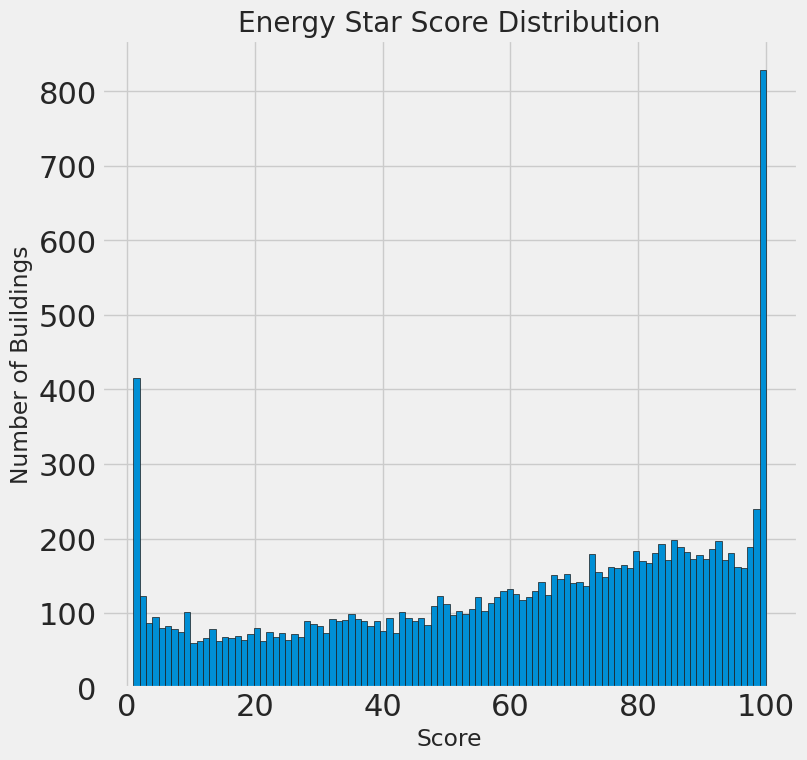

In [10]:
figsize(8,8)
# data = data.rename(columns={'Energy Star Score : score'})
data = data.rename(columns = {'ENERGY STAR Score': 'score'})
plt.style.use('fivethirtyeight')
plt.hist(data['score'].dropna(),bins=100,edgecolor = 'k')
plt.xlabel('Score');plt.ylabel('Number of Buildings');
plt.title('Energy Star Score Distribution')

Text(0.5, 1.0, 'Site EUI Distribution')

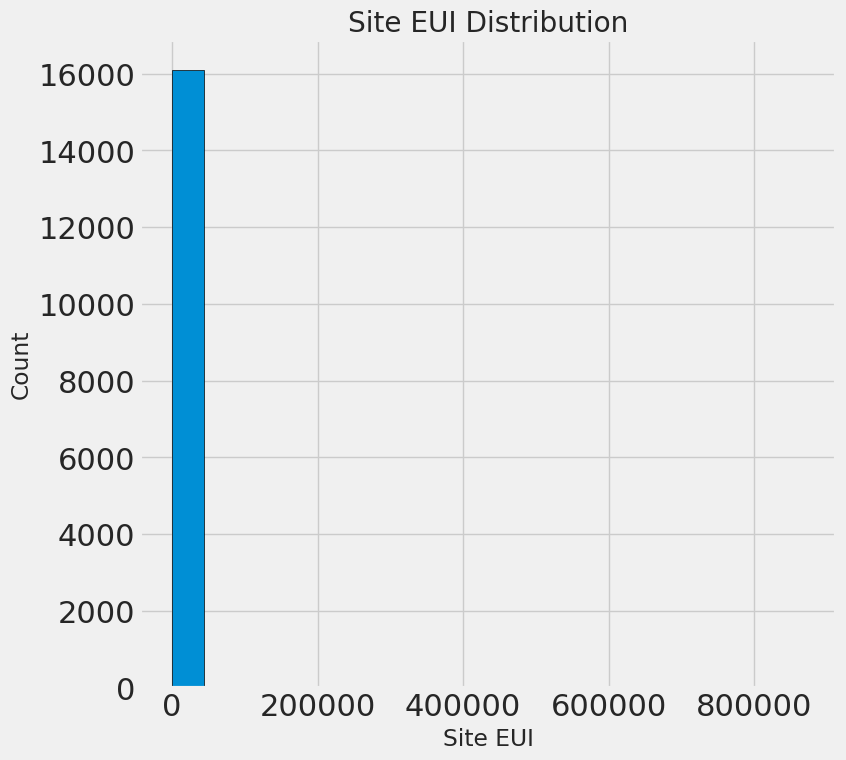

In [11]:
figsize(8,8)
plt.hist(data['Site EUI (kBtu/ft²)'].dropna(),bins=20,edgecolor='Black')
plt.xlabel('Site EUI');
plt.ylabel('Count');plt.title('Site EUI Distribution')

In [12]:
data['Site EUI (kBtu/ft²)'].describe()

,Site EUI (kBtu/ft²)
count,16095.000000
mean,228.991028
std,7300.206821
min,0.000000
25%,60.300000
50%,78.200000
75%,100.250000
max,869265.000000


In [13]:
data['Site EUI (kBtu/ft²)'].dropna().sort_values().tail(10)

,Site EUI (kBtu/ft²)
14058,51328.8
14056,51831.2
2889,78360.1
3102,84969.6
16035,95560.2
3101,103562.7
3100,112173.6
16376,126307.4
9681,143974.4
1635,869265.0


In [15]:
data.loc[data['Site EUI (kBtu/ft²)'] == 869265,:]

,Property Id,Property Name,Parent Property Id,Parent Property Name,Year Ending,"NYC Borough, Block and Lot (BBL)",NYC Building Identification Number (BIN),Address 1,Address 2,City,County,Postcode,Primary Property Type - Self Selected,Primary Property Type - Portfolio Manager-Calculated,National Median Reference Property Type,List of All Property Use Types at Property,Largest Property Use Type,Largest Property Use Type - Gross Floor Area (ft²),2nd Largest Property Use Type,3rd Largest Property Use Type,Year Built,Number of Buildings,Occupancy,Metered Areas (Energy),Metered Areas (Water),score,National Median ENERGY STAR Score,ENERGY STAR Certification - Year(s) Certified,ENERGY STAR Certification - Last Approval Date,ENERGY STAR Certification - Eligibility,...,Alert - Meter has less than 12 full calendar months of data,Alert - No meters are associated with this property,Alert - Property has no uses,Data Quality Checker Run?,Data Quality Checker - Date Run,Default Values,Estimated Values - Energy,Temporary Values,Estimated Values - Water,Property GFA - Calculated (Buildings and Parking) (ft²),Property GFA - Calculated (Buildings) (ft²),Water Current Date,Water Use (All Water Sources) (kgal),Water Use Intensity (All Water Sources) (gal/ft²),Third Party Certification Date Anticipated,Third Party Certification,Third Party Certification Date Achieved,Convenience Store With Gas Station - Number of Open or Closed Refrigeration/Freezer Units,Source EUI (kBtu/ft²),% Difference from National Median Water/Wastewater Source EUI,Source EUI - Adjusted to Current Year (kBtu/ft²),Generation Date,Release Date,Borough,Latitude,Longitude,Community Board,Council District,Census Tract,NTA
1635,"4,414,323",234 Skillman,Not Applicable: Standalone Property,Not Applicable: Standalone Property,12/31/2016,3028937502,"3390250 , 3338313",234 Skillman avenue,Not Available,Bronx,Not Available,11211,Multifamily Housing,Multifamily Housing,Fannie Mae Industry Survey - Multifamily,Multifamily Housing,Multifamily Housing,56900.0,Not Available,Not Available,"2,004",1,90,Whole Building,Not Available,1.0,50,Not Available,Not Available,No,...,Ok,Ok,Ok,No,Not Available,No,No,No,No,56900.0,56900.0,12/31/2016,2547.9,44.78,Not Available,Not Available,Not Available,Not Available,912801.1,Not Available,912801.1,05/01/2017 11:33:49 PM,05/01/2017 11:34:14 PM,BROOKLYN,40.716233,-73.94141,301.0,34.0,477.0,East Williamsburg


In [18]:
first_quartile = data['Site EUI (kBtu/ft²)'].describe()['25%']
third_quartile = data['Site EUI (kBtu/ft²)'].describe()['75%']


# Interquartile range

iqr = third_quartile - first_quartile
# Remove outliers

data = data[(data['Site EUI (kBtu/ft²)'] > (first_quartile - 3 * iqr)) &
            (data['Site EUI (kBtu/ft²)'] < (third_quartile + iqr * 3))]

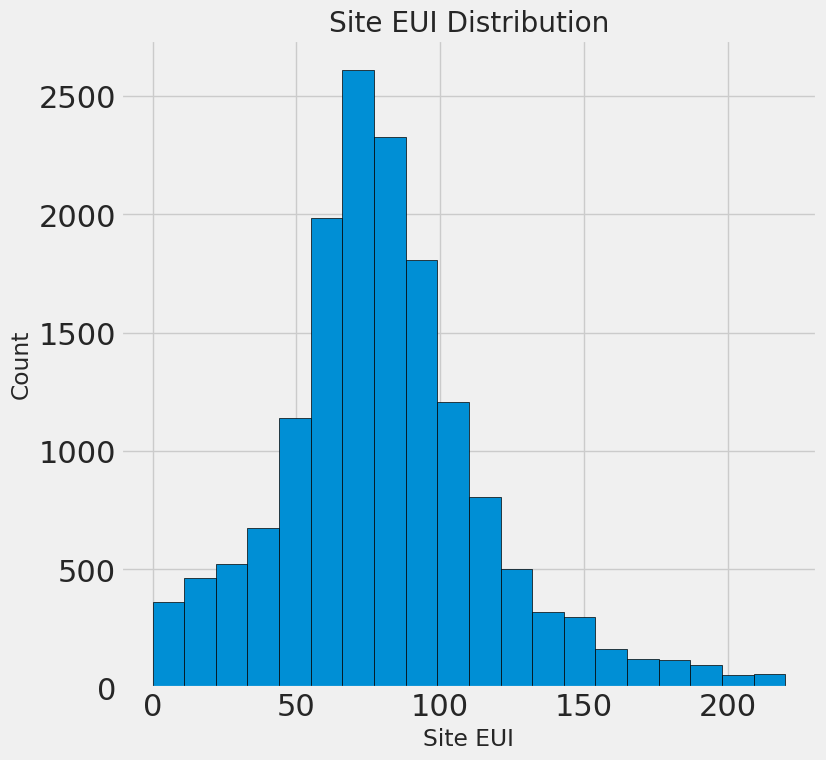

In [19]:
figsize(8,8)
plt.hist(data['Site EUI (kBtu/ft²)'].dropna(),bins=20, edgecolor = 'black');
plt.xlabel('Site EUI');
plt.ylabel('Count');plt.title('Site EUI Distribution');


In [20]:
types = data.dropna(subset=['score'])
types = types['Largest Property Use Type'].value_counts()
types = list(types[types.values > 100 ].index)

/tmp/ipykernel_450/740008522.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(subset['score'].dropna(),label = b_types , shade= False, alpha = 0.8)
/tmp/ipykernel_450/740008522.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(subset['score'].dropna(),label = b_types , shade= False, alpha = 0.8)
/tmp/ipykernel_450/740008522.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(subset['score'].dropna(),label = b_types , shade= False, alpha = 0.8)
/tmp/ipykernel_450/740008522.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=False`.
This will become an error in seaborn v0.14.0; please

Text(0.5, 1.0, 'Density Plot of Energy Star Scores by Building Type')

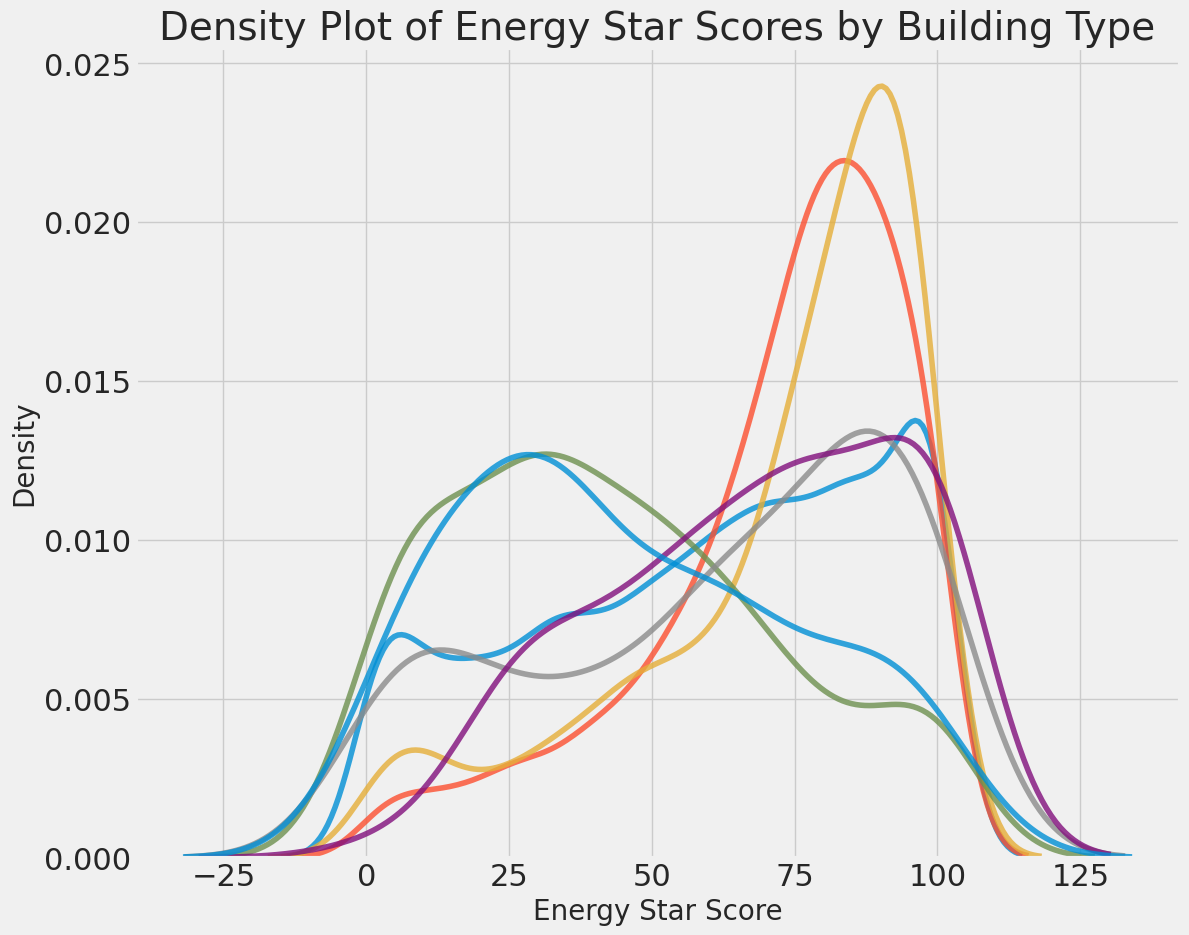

In [21]:
figsize(12,10)
for b_types in types:
  subset = data[data['Largest Property Use Type'] == b_types]
  sns.kdeplot(subset['score'].dropna(),label = b_types , shade= False, alpha = 0.8)

plt.xlabel('Energy Star Score',size= 20); plt.ylabel('Density', size=20);
plt.title('Density Plot of Energy Star Scores by Building Type', size=28)

In [27]:
# Create a list of boroughs with more than 100 observations
boroughs = data.dropna(subset=['score'])
boroughs = boroughs['Borough'].value_counts()
boroughs = list(boroughs[boroughs.values > 100].index)

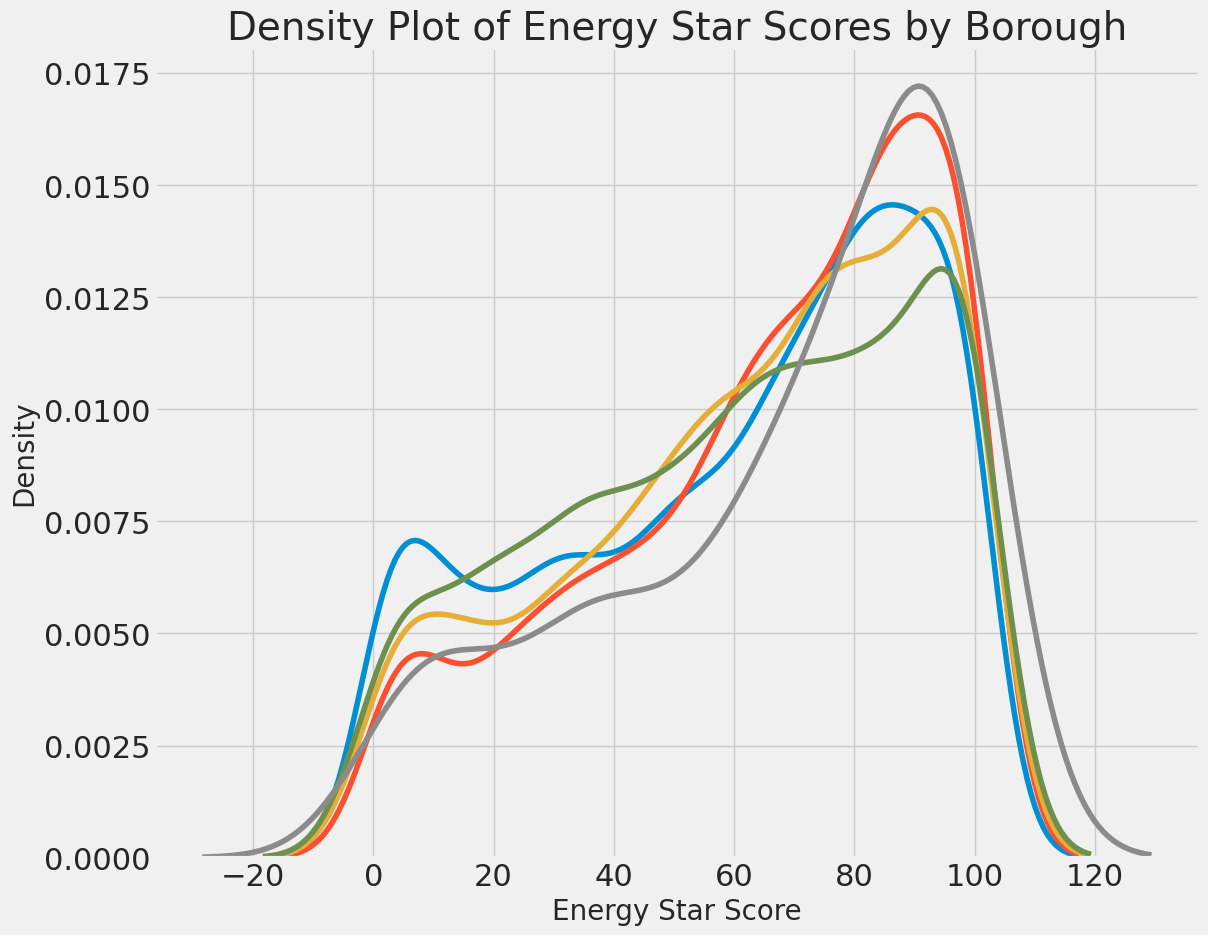

In [28]:
figsize(12, 10)

# Plot each borough distribution of scores
for borough in boroughs:
    # Select the building type
    subset = data[data['Borough'] == borough]

    # Density plot of Energy Star scores
    sns.kdeplot(subset['score'].dropna(),
               label = borough);

# label the plot
plt.xlabel('Energy Star Score', size = 20); plt.ylabel('Density', size = 20);
plt.title('Density Plot of Energy Star Scores by Borough', size = 28);

In [31]:
# correlations_data = data.corr()['score'].sort_values()
correlations_data = data.corr(numeric_only=True)['score'].sort_values()
print(correlations_data.head(15),'\n')
print(correlations_data.tail(15))

Site EUI (kBtu/ft²)                                          -0.717706
Weather Normalized Site EUI (kBtu/ft²)                       -0.706012
Weather Normalized Source EUI (kBtu/ft²)                     -0.644564
Source EUI - Adjusted to Current Year (kBtu/ft²)             -0.642935
Source EUI (kBtu/ft²)                                        -0.640445
Weather Normalized Site Electricity Intensity (kWh/ft²)      -0.386304
Weather Normalized Site Natural Gas Intensity (therms/ft²)   -0.380698
Site Energy Use (kBtu)                                       -0.103269
Net Emissions (Metric Tons CO2e)                             -0.101897
Total GHG Emissions (Metric Tons CO2e)                       -0.101863
Source Energy Use - Adjusted to Current Year (kBtu)          -0.100979
Source Energy Use (kBtu)                                     -0.100179
Weather Normalized Site Energy Use (kBtu)                    -0.097625
Natural Gas Use (kBtu)                                       -0.096650
Weathe

In [33]:
numeric_subset = data.select_dtypes('number')
for col in numeric_subset.columns:
  if col == 'score':
    next
  else :
    numeric_subset['sqrt_' +col] = np.sqrt(numeric_subset[col])
    numeric_subset['log_'+col] = np.log(numeric_subset[col])
categorical_subset = data[['Borough', 'Largest Property Use Type']]
categorical_subset = pd.get_dummies(categorical_subset)
features = pd.concat([numeric_subset,categorical_subset],axis=1)
features = features.dropna(subset = ['score'])
correlations = features.corr()['score'].dropna().sort_values()

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = geta

In [34]:
correlations.head(15)

,score
Site EUI (kBtu/ft²),-0.717706
Weather Normalized Site EUI (kBtu/ft²),-0.706012
sqrt_Site EUI (kBtu/ft²),-0.701430
sqrt_Weather Normalized Site EUI (kBtu/ft²),-0.688064
sqrt_Source EUI - Adjusted to Current Year (kBtu/ft²),-0.676080
sqrt_Weather Normalized Source EUI (kBtu/ft²),-0.675579
sqrt_Source EUI (kBtu/ft²),-0.674433
Weather Normalized Source EUI (kBtu/ft²),-0.644564
Source EUI - Adjusted to Current Year (kBtu/ft²),-0.642935
Source EUI (kBtu/ft²),-0.640445


In [35]:
correlations.tail(15)

,score
log_National Median Source Energy Use (kBtu),0.096147
log_National Median Total GHG Emissions (Metric Tons CO2e),0.096233
National Median Site EUI (kBtu/ft²),0.117475
Largest Property Use Type_K-12 School,0.118957
log_National Median Site EUI (kBtu/ft²),0.122109
Largest Property Use Type_Office,0.127379
sqrt_National Median Site EUI (kBtu/ft²),0.137947
"Multifamily Housing - Number of Residential Living Units in a Mid-Rise Building Density (Number per 1,000 ft²)",0.142734
National Median Source EUI (kBtu/ft²),0.147871
sqrt_National Median Source EUI (kBtu/ft²),0.170965


<Figure size 1200x1000 with 0 Axes>

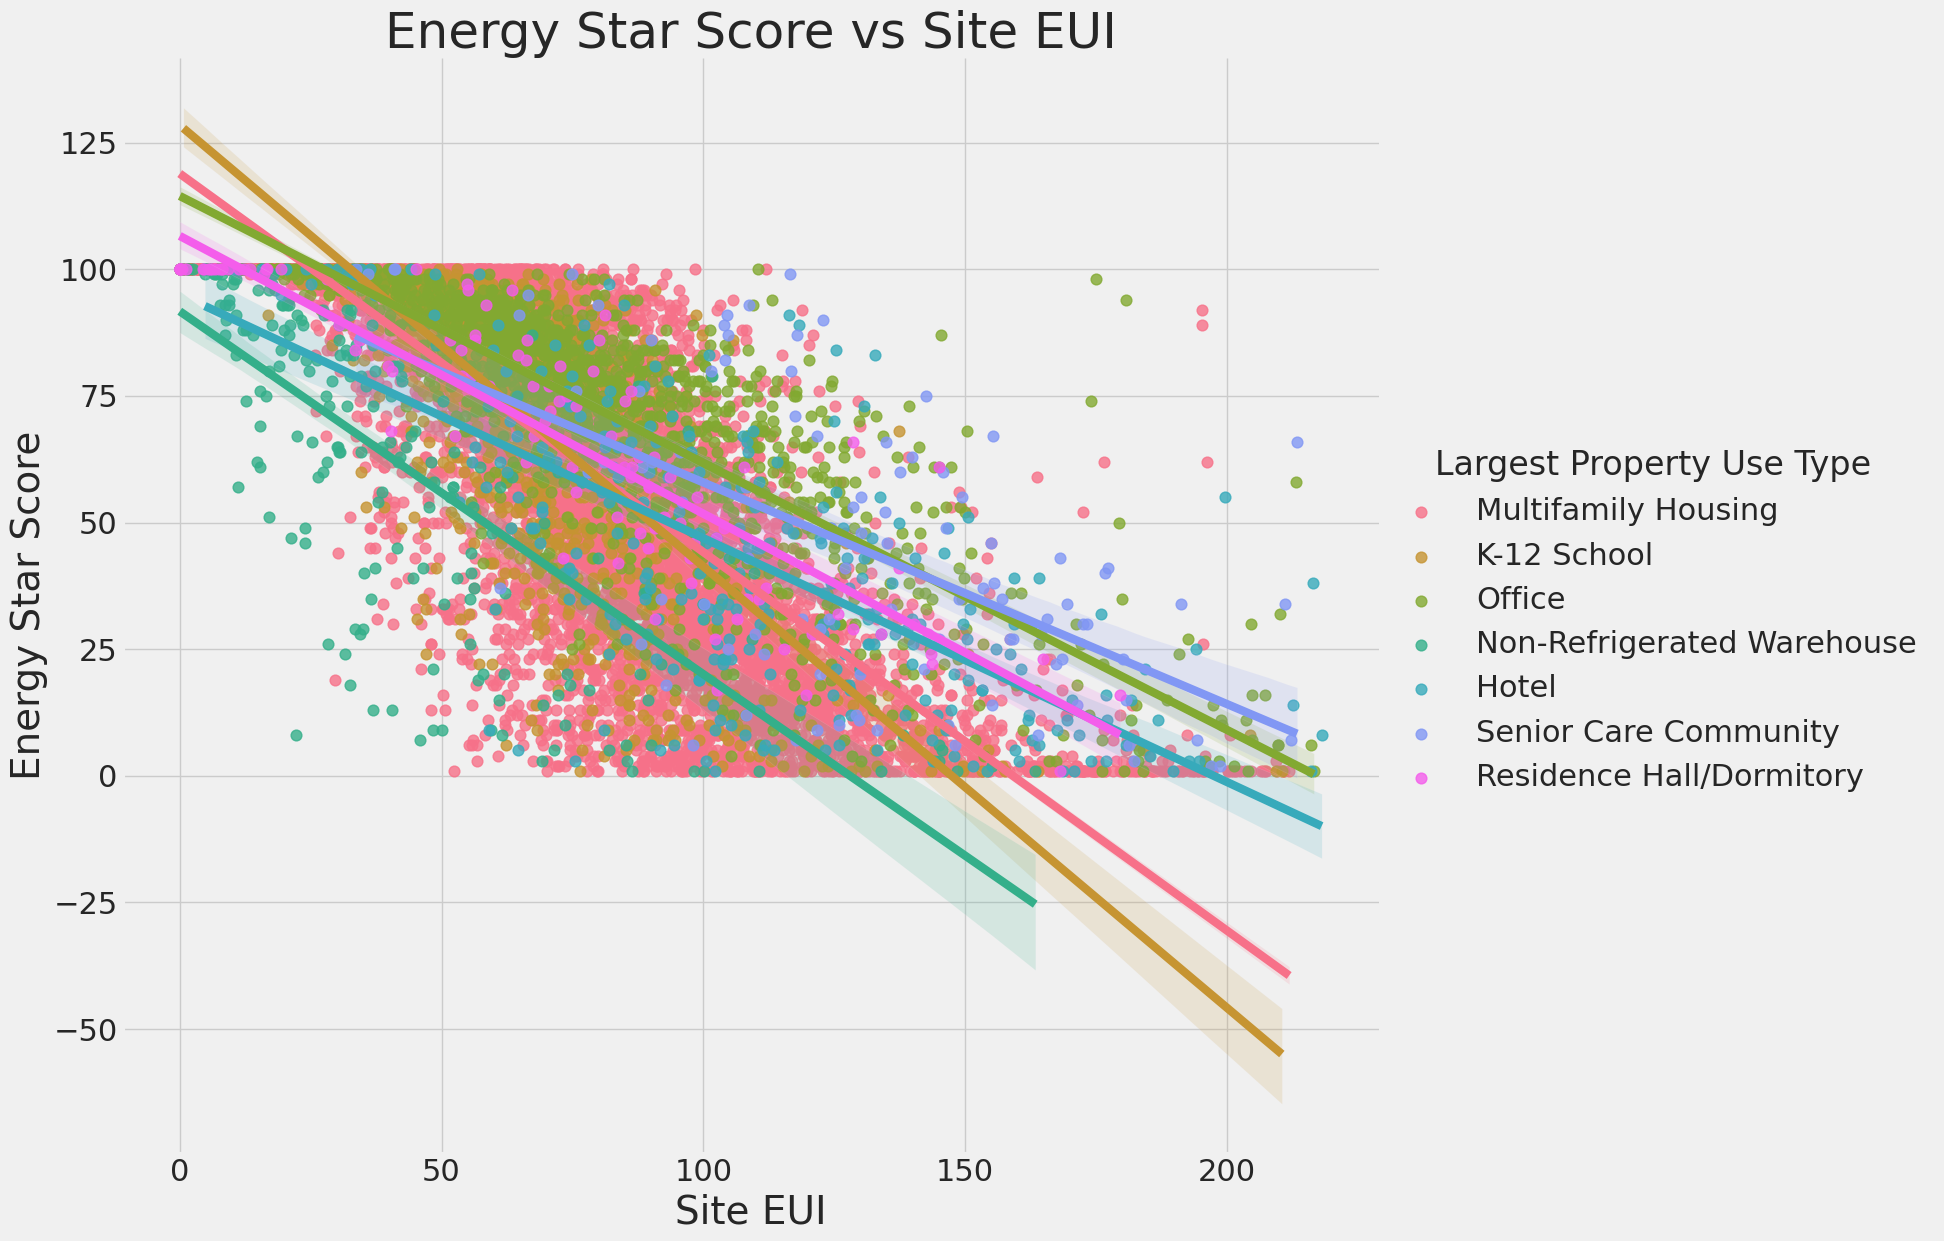

In [38]:
plt.figure(figsize=(12, 10))

# Extract the building types
features['Largest Property Use Type'] = data.dropna(subset=['score'])['Largest Property Use Type']

# Limit to building types with more than 100 observations
features = features[features['Largest Property Use Type'].isin(types)]

# ✅ FIX: Explicitly assign x= and y= keywords, and update 'size' to 'height'
sns.lmplot(
    x='Site EUI (kBtu/ft²)',
    y='score',
    hue='Largest Property Use Type',
    data=features,
    scatter_kws={'alpha': 0.8, 's': 60},
    height=12,
    aspect=1.2
)

# Plot labeling
plt.xlabel("Site EUI", size=28)
plt.ylabel('Energy Star Score', size=28)
plt.title('Energy Star Score vs Site EUI', size=36)

plt.show()

Text(0.5, 1.02, 'Pairs Plot of Energy Data')

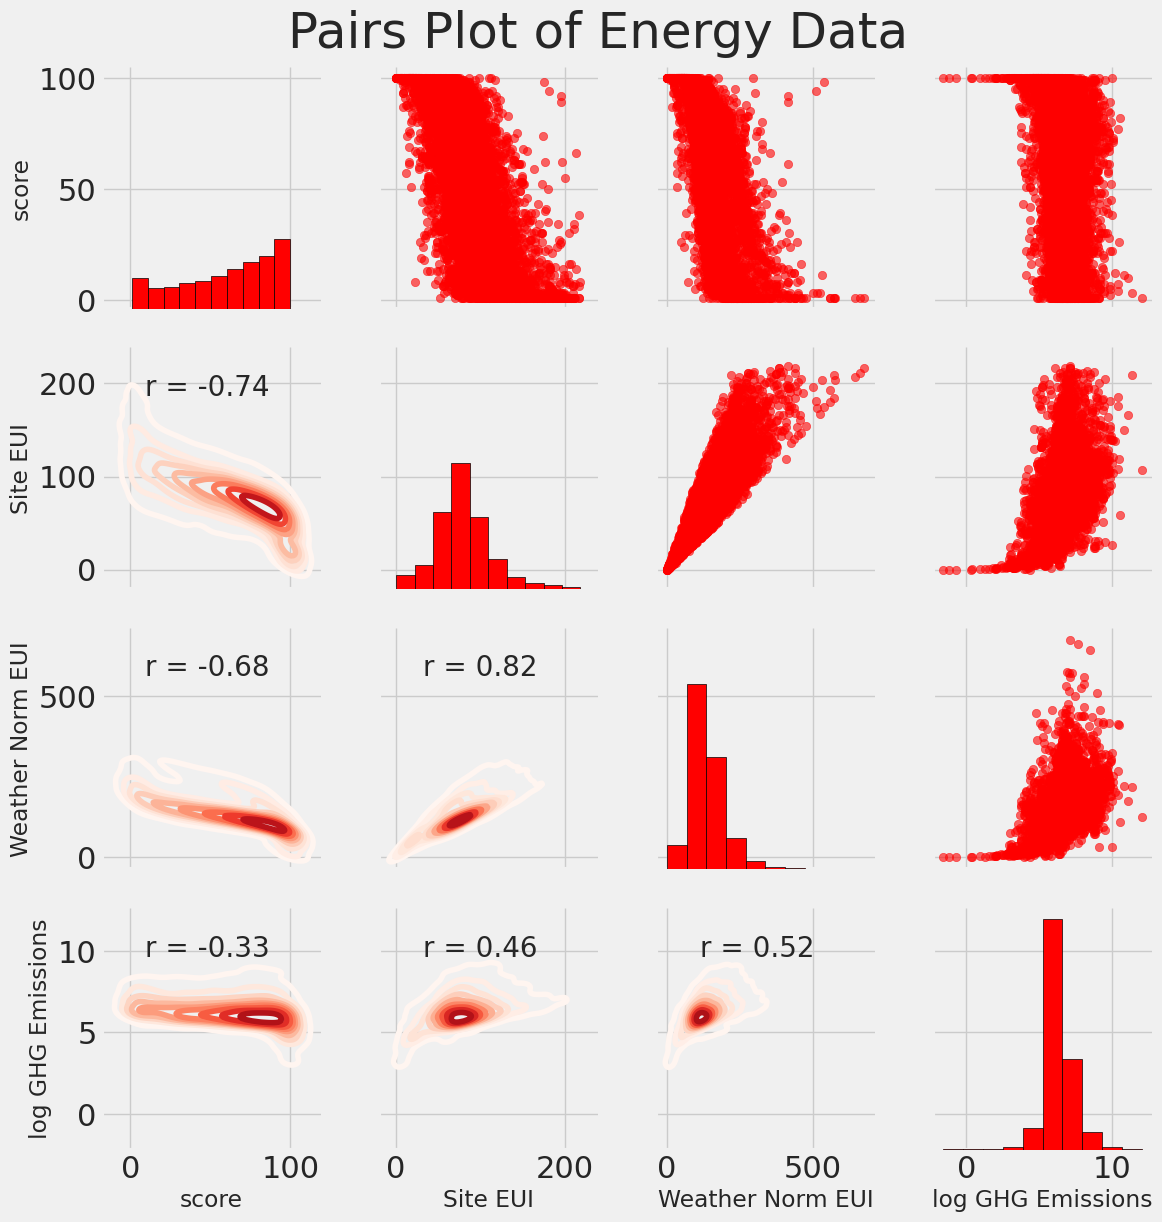

In [42]:
# Extract the columns to plot
plot_data = features[
    [
        'score',
        'Site EUI (kBtu/ft²)',
        'Weather Normalized Source EUI (kBtu/ft²)',
        'log_Total GHG Emissions (Metric Tons CO2e)',
    ]
]

# Replace the inf with nan
plot_data = plot_data.replace({np.inf: np.nan, -np.inf: np.nan})

# Rename columns
plot_data = plot_data.rename(
    columns={
        'Site EUI (kBtu/ft²)': 'Site EUI',
        'Weather Normalized Source EUI (kBtu/ft²)': 'Weather Norm EUI',
        'log_Total GHG Emissions (Metric Tons CO2e)': 'log GHG Emissions',
    }
)

# Drop na values
plot_data = plot_data.dropna()


# Function to calculate correlation coefficient between two columns
def corr_func(x, y, **kwargs):
    r = np.corrcoef(x, y)[0][1]
    ax = plt.gca()
    ax.annotate(
        "r = {:.2f}".format(r),
        xy=(0.2, 0.8),
        xycoords=ax.transAxes,
        size=20,
    )


# ✅ FIX: Change 'size = 3' to 'height = 3'
grid = sns.PairGrid(data=plot_data, height=3)

# Upper is a scatter plot
grid.map_upper(plt.scatter, color='red', alpha=0.6)

# Diagonal is a histogram
grid.map_diag(plt.hist, color='red', edgecolor='black')

# Bottom is correlation and density plot
grid.map_lower(corr_func)
grid.map_lower(sns.kdeplot, cmap=plt.cm.Reds)

# Title for entire plot
plt.suptitle('Pairs Plot of Energy Data', size=36, y=1.02)



In [46]:
# Copy the original data
features = data.copy()

# Select the numeric columns
numeric_subset = data.select_dtypes('number')

# Create columns with log of numeric columns
for col in numeric_subset.columns:
    # Skip the Energy Star Score column
    if col == 'score':
        next
    else:
        numeric_subset['log_' + col] = np.log(numeric_subset[col])

# Select the categorical columns
categorical_subset = data[['Borough', 'Largest Property Use Type']]

# One hot encode
categorical_subset = pd.get_dummies(categorical_subset)

# Join the two dataframes using concat
# Make sure to use axis = 1 to perform a column bind
features = pd.concat([numeric_subset, categorical_subset], axis = 1)

features.shape

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getat

(15628, 158)

Text(0.5, 1.0, 'Weather Norm EUI vs Site EUI, R = 0.9967')

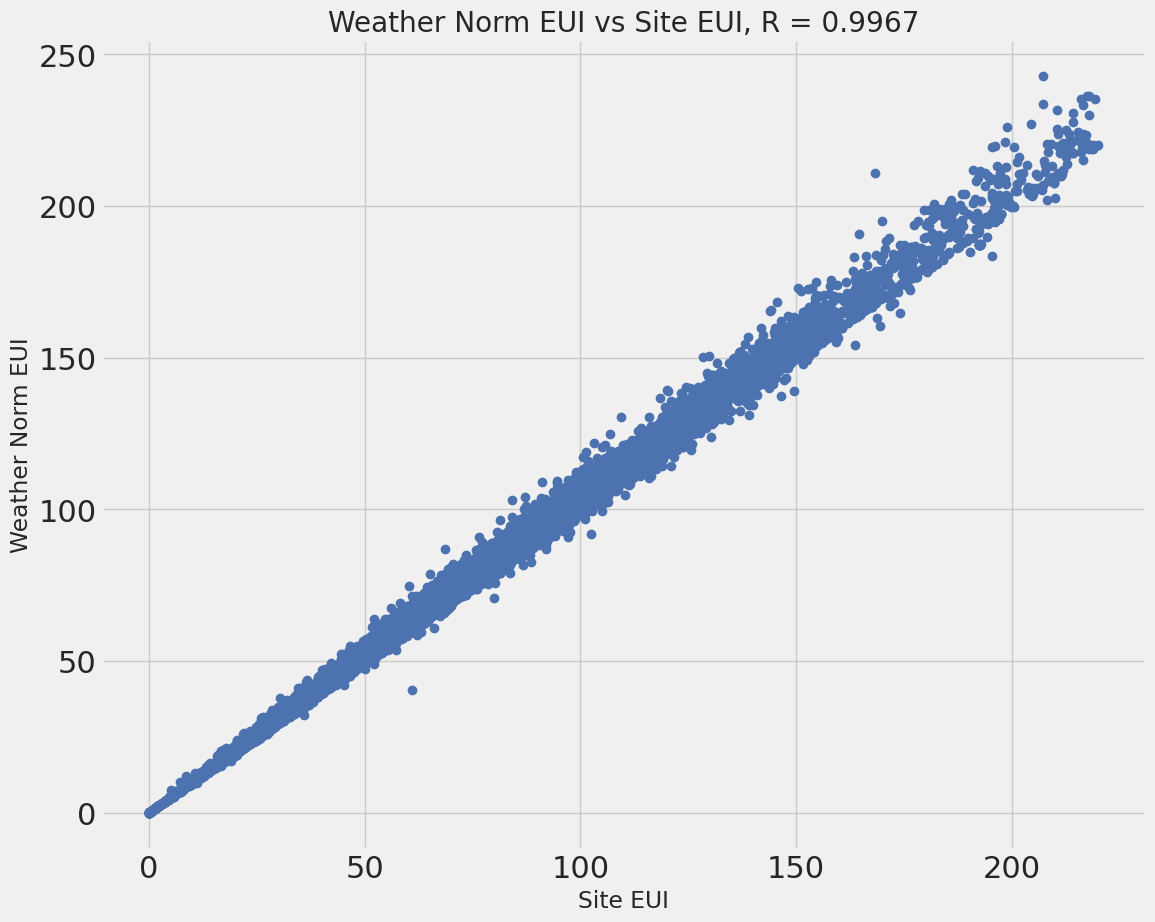

In [48]:
plot_data = data[['Weather Normalized Site EUI (kBtu/ft²)', 'Site EUI (kBtu/ft²)']].dropna()
plt.plot(plot_data['Site EUI (kBtu/ft²)'],plot_data['Weather Normalized Site EUI (kBtu/ft²)'],'bo')
plt.xlabel('Site EUI'); plt.ylabel('Weather Norm EUI');
plt.title('Weather Norm EUI vs Site EUI, R = %0.4f'% np.corrcoef(data[['Weather Normalized Site EUI (kBtu/ft²)', 'Site EUI (kBtu/ft²)']].dropna(),rowvar=False)[0][1])

In [54]:
def remove_collinear_features(x, threshold):
    '''
    Objective:
        Remove collinear features in a dataframe with a correlation coefficient
        greater than the threshold. Removing collinear features can help a model
        to generalize and improves the interpretability of the model.

    Inputs:
        threshold: any features with correlations greater than this value are removed

    Output:
        dataframe that contains only the non-highly-collinear features
    '''

    # Dont want to remove correlations between Energy Star Score
    y = x['score']
    x = x.drop(columns = ['score'])

    # Calculate the correlation matrix
    corr_matrix = x.corr()
    iters = range(len(corr_matrix.columns) - 1)
    drop_cols = []

    # Iterate through the correlation matrix and compare correlations
    for i in iters:
        for j in range(i):
            item = corr_matrix.iloc[j:(j+1), (i+1):(i+2)]
            col = item.columns
            row = item.index
            val = abs(item.values)

            # If correlation exceeds the threshold
            if val >= threshold:
                # Print the correlated features and the correlation value
                # print(col.values[0], "|", row.values[0], "|", round(val[0][0], 2))
                drop_cols.append(col.values[0])

    # Drop one of each pair of correlated columns
    drops = set(drop_cols)
    x = x.drop(columns = drops)
    x = x.drop(columns = ['Weather Normalized Site EUI (kBtu/ft²)',
                          'Water Use (All Water Sources) (kgal)',
                          'log_Water Use (All Water Sources) (kgal)',
                          'Largest Property Use Type - Gross Floor Area (ft²)'])

    # Add the score back in to the data
    x['score'] = y

    return x

In [56]:
# Remove the collinear features above a specified correlation coefficient
features = remove_collinear_features(features, 0.6);

NameError: name 'col_to_remove' is not defined

In [57]:
# Remove any columns with all na values
features  = features.dropna(axis=1, how = 'all')
features.shape

(15628, 157)

In [59]:
no_score = features[features['score'].isna()]
score = features[features['score'].notnull()]

print(no_score)
print(score)

       Largest Property Use Type - Gross Floor Area (ft²)  \
1                                                70000.0    
2                                               114217.0    
4                                                77503.0    
9                                               152011.0    
12                                              102991.0    
...                                                  ...    
16360                                           155000.0    
16362                                            50000.0    
16363                                           106000.0    
16366                                           129642.0    
16375                                           174130.0    

       Number of Buildings  Occupancy  score  \
1                        1        100    NaN   
2                        1         95    NaN   
4                        1        100    NaN   
9                        1        100    NaN   
12                       1 

In [60]:
features = score.drop(columns='score')
target = pd.DataFrame(score['score'])
features = features.replace({np.inf: np.nan, -np.inf: np.nan})
X, X_test, y, y_test = train_test_split(features, targets, test_size = 0.3, random_state = 42)
print(X.shape)
print(X_test.shape)
print(y.shape)
print(y_test.shape)



NameError: name 'targets' is not defined

In [61]:
# Function to calculate mean absolute error
def mae(y_true, y_pred):
    return np.mean(abs(y_true - y_pred))

In [62]:
baseline_guess = np.median(y)

print('The baseline guess is a score of %0.2f' % baseline_guess)
print("Baseline Performance on the test set: MAE = %0.4f" % mae(y_test, baseline_guess))

NameError: name 'y' is not defined